In [47]:
#!pip install numpy scikit-learn matplotlib

In [48]:
import numpy as np
import sklearn
import matplotlib

from sklearn.datasets import load_digits

In [49]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [50]:
data = digits["data"]
images = digits["images"]
target = digits["target"]
target_names = digits["target_names"]

data[0].shape, images[0].shape, target[0], target_names[0]

((64,), (8, 8), np.int64(0), np.int64(0))

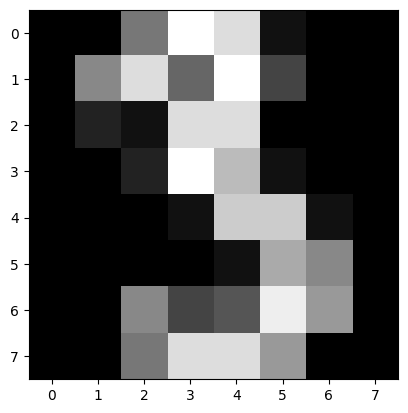

In [51]:
import numpy as np
import matplotlib . pyplot as plt
img = images[target == 3][0]
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [52]:
filte = (target % 3 == 0) * (target % 2 != 0)

filtered_data = data[filte]
filtered_target = target[filte]

filtered_target[filtered_target==3] = -1
filtered_target[filtered_target==9] = 1

filtered_target

array([-1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
        1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,
        1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,
        1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,
        1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1, -1

In [53]:
from sklearn import model_selection

X_all = filtered_data #/ 255
y_all = filtered_target

X_train, X_test, y_train, y_test =\
    model_selection.train_test_split(X_all, y_all,
        test_size = 0.4 , random_state = 0)

(8, 8)


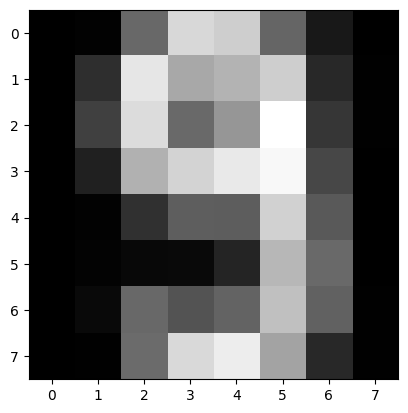

In [54]:
img = X_train[y_train == 1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


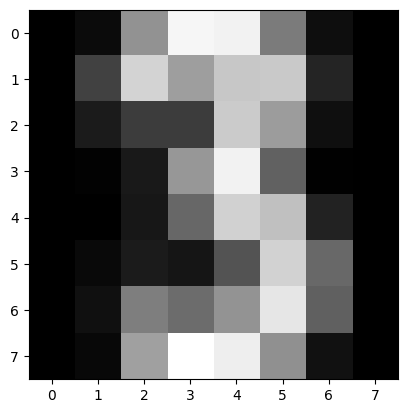

In [55]:
import numpy as np
import matplotlib . pyplot as plt
img = X_train[y_train == -1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


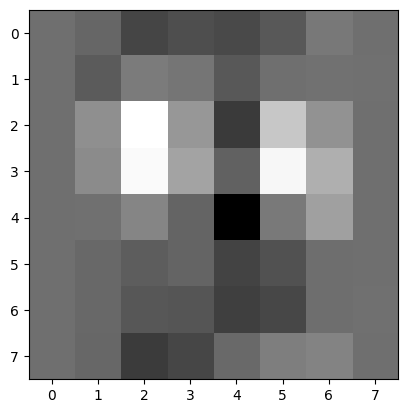

In [56]:
import numpy as np
import matplotlib . pyplot as plt
img = (X_train[y_train == 1].mean(axis=0) - X_train[y_train == -1].mean(axis=0)).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [57]:
def handcrafted_conv(x):
    
    conv_matrix = np.array([[0,0,0,0], [0,0,0,0], [0.5, -1, 1, -0.5], [0.5, -1, 1, -0.5]])
    
    
    print((x * conv_matrix).shape)
    
    val = (x[:] * conv_matrix).sum(axis=2).sum(axis=1)
    
    return val


def features2d(x: np.array):
    
    f_1 = 0
    
    f_1 = x[:, 2*8+2] + x[:, 3*8+2] - 15# * 2 #- x[:, 2*8+1] * 2
    #for i in range(1):
     #   sub_matrix = np.array([x[:, 4*i:4*i+4], x[:, 4*i+8:4*i+12], x[:, 4*i+16:4*i+20], x[:, 4*i+24:4*i+28]]).reshape((x.shape[0], 4, 4))
      #  f_1 += handcrafted_conv(sub_matrix)
    
    #print(f_1)
    
    f_2 = 0
    #for i in range(2):
     #   sub_matrix = np.array([x[:, 4*i+32:4*i+4+32], x[:, 4*i+8+32:4*i+12+32], x[:, 4*i+16+32:4*i+20+32], x[:, 4*i+24+32:4*i+28+32]]).reshape((x.shape[0], 4, 4))
      #  f_2 += handcrafted_conv(sub_matrix)
    
    #f_2 = (x[:, 3*8+2]*3 - x[:, 3*8+3] - x[:, 7*8+2] ** 4 / 1000 - x[:, 7*8+1] ** 4 / 1000 + x[:, 3*8+5] ** 3 / 8 + x[:, 3*8+6] * 100 - x[:, 2*8+6] * 100) / 20
    #f_2 = (-x[:, 7*8+2] ** 10  + x[:, 3*8+5] ** 10) / 100000000000 +( x[:, 3*8+7] ** 4 - x[:, 7*8+1] ** 4) / 10000
    
    f_2 = x[:, 2*8+5] *0.5 + x[:, 3*8+5] - 15
    
    #print(f_2)
    
        
    return f_1, f_2

In [58]:

def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [59]:
X_train[:4]

array([[ 0.,  0.,  0.,  1., 12., 16., 14.,  0.,  0.,  0.,  3., 14., 13.,
        15., 13.,  0.,  0.,  4., 16., 15., 13., 16.,  4.,  0.,  0.,  3.,
        16., 16., 16., 16.,  3.,  0.,  0.,  0.,  7.,  7., 14., 14.,  0.,
         0.,  0.,  0.,  0.,  0., 12., 11.,  0.,  0.,  0.,  0.,  0.,  0.,
        13., 10.,  0.,  0.,  0.,  0.,  0.,  0., 13., 12.,  0.,  0.],
       [ 0.,  0.,  9., 16., 14.,  6.,  0.,  0.,  0.,  6., 16.,  5., 10.,
        16.,  0.,  0.,  0.,  2., 15.,  7., 10., 16.,  3.,  0.,  0.,  0.,
         4.,  8., 12., 16.,  4.,  0.,  0.,  0.,  0.,  0.,  0., 16.,  7.,
         0.,  0.,  0.,  0.,  0.,  1., 16.,  8.,  0.,  0.,  0.,  3.,  0.,
         8., 16.,  1.,  0.,  0.,  0., 10., 16., 13.,  4.,  0.,  0.],
       [ 0.,  0.,  8., 14., 12.,  3.,  0.,  0.,  0.,  6., 16.,  6., 14.,
        14.,  0.,  0.,  0.,  6., 13.,  0.,  8., 14.,  0.,  0.,  0.,  2.,
        14., 14., 14., 16.,  3.,  0.,  0.,  0.,  2.,  4.,  6., 16.,  5.,
         0.,  0.,  0.,  0.,  0.,  0., 16.,  5.,  0.,  0.,  

In [60]:
x = X_train

print(x.shape)


features = features2d(x)

(217, 64)


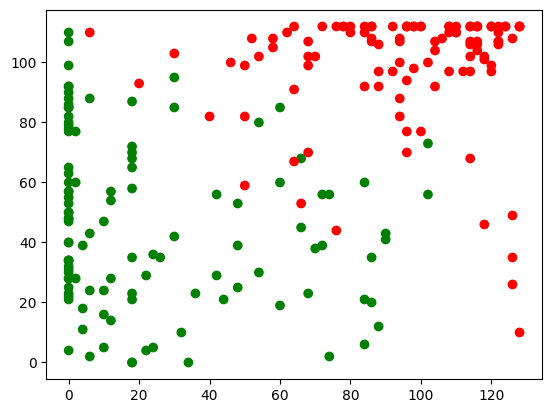

In [61]:
#print(features)

features = features2d(x)

color_dict = {-1: "green", 1: "red"} # Where green is 3s and red is 9s
colors = [color_dict[y] for y in y_train]

matplotlib.pyplot.scatter(features[0], features[1], c=colors)

In [62]:

def nearest_mean(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
            
    #predicted_labels = np.array([1 if abs(x_9_mean**2 + y_9_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) < abs(x_3_mean**2 + y_3_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) else -1 for i in range(len(test_features[0]))])
    predicted_labels = np.array([1 if abs((x_9_mean - test_features[0][i])**2 + (y_9_mean - test_features[1][i])**2) < (x_3_mean - test_features[0][i])**2 + (y_3_mean - test_features[1][i])**2 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

def descision_function(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
    
    beta1 = 1/210
    beta2 = 1/220
    b1 = -0.5
    b2 = -0.5
            
    predicted_labels = np.array([1 if (test_features[0][i]*beta1 + b1) + (test_features[1][i]*beta2 + b2) > 0 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

In [63]:
training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)

In [64]:
predicted_labels

array([ 1,  1,  1, -1, -1,  1,  1,  1, -1, -1, -1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1,
       -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
        1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

In [65]:
#F P +#F N
#    N

def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N
    

In [66]:
true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)

In [67]:
errors

(np.int64(70),
 np.int64(65),
 np.int64(7),
 np.int64(4),
 146,
 np.float64(0.07534246575342465),
 np.float64(0.9246575342465754))

In [68]:


def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 4 + x[:, 3*8+2] * 8#- 15# * 2 #- x[:, 2*8+1] * 2

    f_2 = x[:, 2*8+5] * 5 + x[:, 3*8+5] * 9#- 15

        
    return f_1, f_2


training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)
predicted_labels2 = descision_function(training_features, training_labels, test_features)

true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)
errors2 = calculate_errors(predicted_labels2, true_labels)

errors[-1], errors[-2], errors2[-1], errors2[-2]

(np.float64(0.9794520547945206),
 np.float64(0.02054794520547945),
 np.float64(0.9794520547945206),
 np.float64(0.02054794520547945))

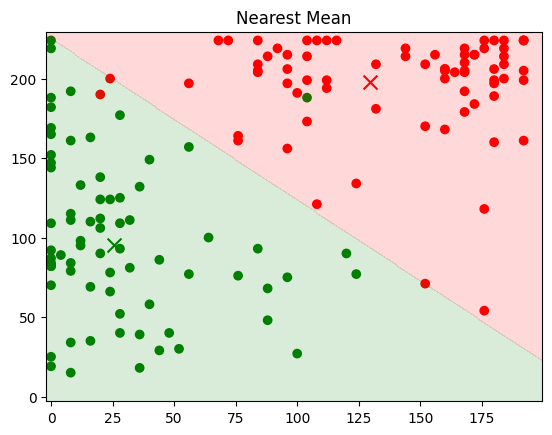

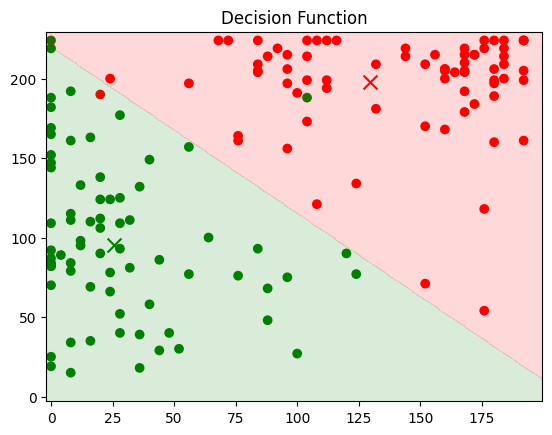

In [69]:
import matplotlib.pyplot as plt
import numpy as np


#fig, ax = plt.subplots()


color_dict = {-1: "green", 1: "red"}
colors = [color_dict[y] for y in true_labels]

#ax.scatter(test_features[0], test_features[1], c=colors)

x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()

xx, yy = np.meshgrid(np.arange(-2, 200, 0.5), np.arange(-3, 230, 0.5))
grid = (xx.ravel(), yy.ravel())

for func, name in [(nearest_mean, "Nearest Mean"), (descision_function, "Decision Function")]:
    fig, ax = plt.subplots()
    colors = [color_dict[y] for y in true_labels]
    ax.scatter(test_features[0], test_features[1], c=colors)
    ax.scatter(x_9_mean, y_9_mean, c="red", marker="x", s=100)
    ax.scatter(x_3_mean, y_3_mean, c="green", marker="x", s=100)

    Z = func(training_features, training_labels, grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["green", "red"], alpha=0.15)
    ax.set_title(name)
    plt.show()


# LDA

In [70]:
variance = np.var(X_train, axis=0)
mask = variance > 0.001
X_train_filtered = X_train[:, mask]
X_test_filtered = X_test[:, mask]

def fit_lda(training_features, training_labels):

    if isinstance(training_features, tuple) or isinstance(training_features, list):
        training_features = np.array(training_features).T
    training_features = np.asarray(training_features)
    training_labels = np.asarray(training_labels)

    # Compute class means
    mu_minus1 = training_features[training_labels == -1].mean(axis=0)
    mu_1 = training_features[training_labels == 1].mean(axis=0)

    # Compute class covariances
    X_minus1 = training_features[training_labels == -1]
    X_minus1_centered = X_minus1 - mu_minus1
    X_1 = training_features[training_labels == 1]
    X_1_centered = X_1 - mu_1

    cov_minus1 = X_minus1_centered.T @ X_minus1_centered
    cov_1 = X_1_centered.T @ X_1_centered
    covmat = (cov_minus1 + cov_1) / training_features.shape[0]

    mu = np.vstack([mu_minus1, mu_1])

    # priors
    N = training_features.shape[0]
    N_minus1 = (training_labels == -1).sum()
    N_1 = (training_labels == 1).sum()
    p = np.array([N_minus1 / N, N_1 / N])

    return mu, covmat, p


In [71]:
mu, covmat, p = fit_lda(training_features, training_labels)

def predict_lda(mu, covmat, p, test_features):
    """Predict labels using LDA parameters. Returns array of {-1,1}."""
    # support tuple input (features2d) or numpy array
    if isinstance(test_features, tuple):
        X = np.array(test_features).T
    else:
        X = np.array(test_features)

    inv_covmat = np.linalg.inv(covmat)
    mu_minus1 = mu[0]
    mu_1 = mu[1]

    beta = inv_covmat @ (mu_1 - mu_minus1)
    b = -0.5 * (mu_1 + mu_minus1) @ beta + np.log(p[1] / p[0])

    scores = X @ beta + b
    predicted_labels = np.where(scores > 0, 1, -1)
    return predicted_labels


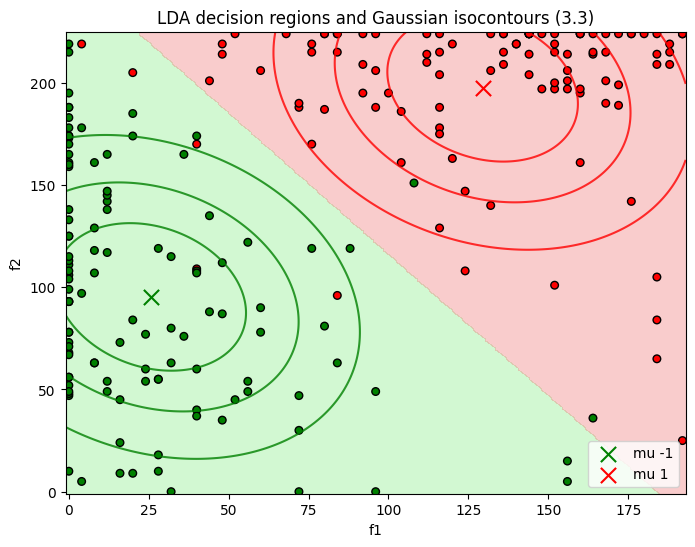

In [72]:
# LDA visualization: decision regions + Gaussian isocontours (Aufgabe 3.3)
import matplotlib.pyplot as plt
from matplotlib import cm

# prepare 2D features and labels
train_f2 = features2d(X_train)
Xf2_train = np.array(train_f2).T
Xf2_test = np.array(features2d(X_test)).T
y_train_m = y_train.copy(); y_train_m[y_train_m==3] = -1; y_train_m[y_train_m==9] = 1
y_test_m  = y_test.copy();  y_test_m[y_test_m==3]   = -1; y_test_m[y_test_m==9]   = 1

# fit LDA on the 2D features
mu2, cov2, p2 = fit_lda(Xf2_train, y_train_m)

# grid for plotting decision regions
pad = 1.0
x_min, x_max = Xf2_train[:,0].min() - pad, Xf2_train[:,0].max() + pad
y_min, y_max = Xf2_train[:,1].min() - pad, Xf2_train[:,1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# predict grid labels with our LDA
Z = predict_lda(mu2, cov2, p2, grid).reshape(xx.shape)

# plot decision regions
fig, ax = plt.subplots(figsize=(8,6))
ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["lightgreen", "lightcoral"], alpha=0.4)

# plot training points
colors = ["green" if y == -1 else "red" for y in y_train_m]
ax.scatter(Xf2_train[:,0], Xf2_train[:,1], c=colors, edgecolor='k', s=30)
ax.scatter(mu2[0][0], mu2[0][1], c='green', marker='x', s=120, label='mu -1')
ax.scatter(mu2[1][0], mu2[1][1], c='red',   marker='x', s=120, label='mu 1')

# overlay Gaussian isocontours using the pooled covariance (cov2)
# handle potential singularity
try:
    inv_cov2 = np.linalg.inv(cov2)
    det_cov2 = np.linalg.det(cov2)
except Exception:
    inv_cov2 = np.linalg.pinv(cov2)
    det_cov2 = max(np.linalg.det(cov2), 1e-12)

norm_const = 1.0 / (2 * np.pi * np.sqrt(max(det_cov2, 1e-12)))
for mu_c, col in [(mu2[0], 'green'), (mu2[1], 'red')]:
    diffs = grid - mu_c
    exponents = -0.5 * np.einsum('ij,ij->i', diffs @ inv_cov2, diffs)
    pdf = norm_const * np.exp(exponents)
    pdf2 = pdf.reshape(xx.shape)
    levels = np.linspace(pdf2.min(), pdf2.max(), 5)[1:]
    ax.contour(xx, yy, pdf2, levels=levels, colors=col, alpha=0.8)

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_title('LDA decision regions and Gaussian isocontours (3.3)')
ax.legend()
plt.show()


In [73]:
# Aufgabe 3.4: 10-fold CV + sklearn comparison (2D features)
from sklearn.model_selection import KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA

# Prepare 2D data
train_f2 = features2d(X_train)
Xf2_full = np.array(train_f2).T  # Shape (N, 2)
y_full = y_train.copy()
y_full[y_full == 3] = -1
y_full[y_full == 9] = 1

print("=" * 60)
print("Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich")
print("=" * 60)

# 10-fold CV for our LDA implementation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
our_cv_errors = []
sklearn_cv_errors = []

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(Xf2_full)):
    X_train_fold = Xf2_full[train_idx]
    y_train_fold = y_full[train_idx]
    X_test_fold = Xf2_full[test_idx]
    y_test_fold = y_full[test_idx]
    
    # Our implementation
    mu_fold, cov_fold, p_fold = fit_lda(X_train_fold, y_train_fold)
    preds_our = predict_lda(mu_fold, cov_fold, p_fold, X_test_fold)
    error_our = (preds_our != y_test_fold).mean()
    our_cv_errors.append(error_our)
    
    # sklearn LDA (uses label {-1, 1} natively)
    lda_sklearn = SklearnLDA()
    lda_sklearn.fit(X_train_fold, y_train_fold)
    preds_sklearn = lda_sklearn.predict(X_test_fold)
    error_sklearn = (preds_sklearn != y_test_fold).mean()
    sklearn_cv_errors.append(error_sklearn)
    
    print(f"Fold {fold_idx+1:2d}: Our LDA error={error_our:.4f}, sklearn error={error_sklearn:.4f}")

print("\n" + "=" * 60)
print(f"Our LDA:    Mean CV error = {np.mean(our_cv_errors):.4f} ± {np.std(our_cv_errors):.4f}")
print(f"sklearn LDA: Mean CV error = {np.mean(sklearn_cv_errors):.4f} ± {np.std(sklearn_cv_errors):.4f}")
print("=" * 60)

# Test on full train/test split
mu_full, cov_full, p_full = fit_lda(Xf2_full, y_full)
Xf2_test = np.array(features2d(X_test)).T
y_test_m = y_test.copy()
y_test_m[y_test_m == 3] = -1
y_test_m[y_test_m == 9] = 1

preds_our_full = predict_lda(mu_full, cov_full, p_full, Xf2_full)
preds_our_test = predict_lda(mu_full, cov_full, p_full, Xf2_test)
train_error_our = (preds_our_full != y_full).mean()
test_error_our = (preds_our_test != y_test_m).mean()

lda_sklearn_full = SklearnLDA()
lda_sklearn_full.fit(Xf2_full, y_full)
preds_sklearn_full = lda_sklearn_full.predict(Xf2_full)
preds_sklearn_test = lda_sklearn_full.predict(Xf2_test)
train_error_sklearn = (preds_sklearn_full != y_full).mean()
test_error_sklearn = (preds_sklearn_test != y_test_m).mean()

print("\nTrain/Test Split Results (2D features):")
print(f"Our LDA:     Train error={train_error_our:.4f}, Test error={test_error_our:.4f}")
print(f"sklearn LDA: Train error={train_error_sklearn:.4f}, Test error={test_error_sklearn:.4f}")
print("=" * 60)


Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich
Fold  1: Our LDA error=0.0455, sklearn error=0.0455
Fold  2: Our LDA error=0.0455, sklearn error=0.0455
Fold  3: Our LDA error=0.0000, sklearn error=0.0000
Fold  4: Our LDA error=0.0455, sklearn error=0.0455
Fold  5: Our LDA error=0.0000, sklearn error=0.0000
Fold  6: Our LDA error=0.0000, sklearn error=0.0000
Fold  7: Our LDA error=0.0455, sklearn error=0.0455
Fold  8: Our LDA error=0.0952, sklearn error=0.0952
Fold  9: Our LDA error=0.0000, sklearn error=0.0000
Fold 10: Our LDA error=0.0476, sklearn error=0.0476

Our LDA:    Mean CV error = 0.0325 ± 0.0301
sklearn LDA: Mean CV error = 0.0325 ± 0.0301

Train/Test Split Results (2D features):
Our LDA:     Train error=0.0323, Test error=0.0274
sklearn LDA: Train error=0.0323, Test error=0.0274


# SVM

In [74]:
# For Graphing Later
losses = []
training_errors = []

def fit_svm(training_features, training_labels):
    if type(training_features) == tuple:
        training_features = np.array(training_features).reshape(training_labels.shape[0], -1)
        
    
    n = training_features.shape[0]

    beta = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lamb = 1
    tau = .1
    
    #print(training_labels.shape, training_features.shape, beta.shape)
    
    #print((training_labels * (training_features @ beta + b)).shape)
    
    loss_old = 100000
    count = 0
    
    for x in range(10000):
        
        
        mask = (1 - training_labels * (training_features @ beta + b)) > 0


        beta = beta - tau * lamb/n * (-training_labels[mask] @ training_features[mask]).sum()
        b = b - tau * lamb/n * (-training_labels[mask]).sum()
        
        loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
        losses.append(loss) # Need to visualize the Loss

        predicted = predict_svm(training_features, beta, b)
        iteration_error = calculate_errors(predicted, training_labels)[5]
        training_errors.append(iteration_error) # Need to visualize the training error
        
        if loss >= loss_old and count >= 10:
            count = 0
            tau *= 0.5
        elif loss >= loss_old and count < 10:
            count += 1
        else:
            loss_old = loss
         
        #tau *= 0.999
    
    #print(1- training_labels * (training_features @ beta + b))
        
    print(loss)
    
    

    return beta, b


def predict_svm(test_features, beta, b):
    
    if type(test_features) == tuple:
        test_features = np.array(test_features).T
    
    
    #print(test_features)
    
    predicted_labels = test_features @ beta + b
    
    #print(predicted_labels)
    
    predicted_labels = predicted_labels * -1
    
    predicted_labels[predicted_labels > 0] = 1
    predicted_labels[predicted_labels < 0] = -1
    
    return predicted_labels

In [75]:
def search_lambda(training_features, training_labels):
    
    if type(training_features) == tuple:        
        training_features = np.array(training_features).T
    
    
    split = training_features.shape[0] // 5
    validation_features, validation_labels = training_features[:split], training_labels[:split]
    training_features, training_labels   = training_features[split:], training_labels[split:]
    

    
    

    n = training_features.shape[0]
    
    beta0 = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lambs = np.logspace(-4, 2, num=7)

    
    print(lambs)
    
    
    
    
    tau = 1
    
    best_lambda = 1
    best_beta = None
    best_b = None
    
        
    best_loss = 100000
    
    for lamb in lambs:
        loss_old = 100000
        count = 0
        
        beta = beta0.copy()
        b = 0
        
        tau = 1
        
        for x in range(10000):
            
            
            mask = (1 - training_labels * (training_features @ beta + b)) > 0
            
            grad_beta = beta + lamb/n * (-training_labels[mask, np.newaxis] * training_features[mask]).sum(axis=0)
            
            beta = beta - tau * grad_beta
            
            
            grad_b = lamb/n * (-training_labels[mask]).sum()
            b = b - tau * grad_b
            
            loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
            
            #if loss >= loss_old and count >= 10:
             #   count = 0
              #  tau *= 0.9
            #elif loss >= loss_old and count < 10:
             #   count += 1
            #else:
             #   loss_old = loss

            tau *= 0.99
        
        valid_loss = 1/2 * beta @ beta.T + 1/n * (np.maximum(0, 1 - validation_labels * (validation_features @ beta + b))).sum()
        
        predicted_labels = predict_svm(validation_features, beta, b)
        
        #print(predicted_labels)
        
        errors = calculate_errors(predicted_labels, validation_labels)
        
        print(f"lambda: {lamb}, training loss: {loss:.4f}, validation loss: {valid_loss:.4f}, valid acc: {errors[5]:.4f}, valid error: {errors[6]:.4f}, best loss:{best_loss:.4f}")
        
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_lambda = lamb.copy()
            best_beta = beta.copy()
            best_b = b.copy()
    

    print(best_lambda)
    
    return best_lambda, best_beta, best_b

best_lambda = search_lambda(X_train, y_train)
best_lambda

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2447, valid acc: 0.4884, valid error: 0.5116, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2234, valid acc: 0.4884, valid error: 0.5116, best loss:0.2447
lambda: 0.01, training loss: 0.0055, validation loss: 0.0810, valid acc: 1.0000, valid error: 0.0000, best loss:0.2234
lambda: 0.1, training loss: 0.0168, validation loss: 0.0306, valid acc: 1.0000, valid error: 0.0000, best loss:0.0810
lambda: 1.0, training loss: 0.0473, validation loss: 0.0435, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
lambda: 10.0, training loss: 0.9926, validation loss: 0.9968, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
lambda: 100.0, training loss: 55.2955, validation loss: 55.2955, valid acc: 1.0000, valid error: 0.0000, best loss:0.0306
0.1


(np.float64(0.1),
 array([ 0.00000000e+00, -4.28252526e-03, -2.86145477e-03, -5.59811540e-03,
        -2.10520161e-02, -2.23993232e-02, -1.47349569e-03,  8.56000689e-07,
         0.00000000e+00, -9.36471224e-03, -1.76995904e-04, -4.35823330e-03,
        -3.35271250e-03, -1.23860081e-03, -3.63980409e-03,  1.52802944e-05,
         0.00000000e+00,  1.14748197e-02,  4.18335449e-02,  2.99196457e-02,
        -2.61843444e-03,  4.96873398e-02,  9.30604682e-03,  1.17509324e-05,
         0.00000000e+00,  1.88335440e-02,  5.55346745e-02,  2.57257060e-02,
        -8.66314258e-03,  5.35405350e-02,  2.55919800e-02,  0.00000000e+00,
         0.00000000e+00,  1.20521316e-03,  9.40188064e-03,  2.57396845e-03,
        -3.65840543e-02,  4.64380593e-03,  4.40617259e-03,  0.00000000e+00,
         0.00000000e+00, -4.43298559e-03, -2.06245729e-02, -6.20923964e-03,
        -1.73139742e-02, -1.52464854e-02, -2.04896218e-02,  0.00000000e+00,
         0.00000000e+00, -3.56767037e-03, -1.16953475e-02, -6.13311659

In [76]:
def for_svm_features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [77]:
_, beta, b = search_lambda(X_train, y_train)

_, beta_2, b_2 = search_lambda(for_svm_features2d(X_train), y_train)
beta, b, beta_2, b_2

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2447, valid acc: 0.4884, valid error: 0.5116, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2234, valid acc: 0.4884, valid error: 0.5116, best loss:0.2447
lambda: 0.01, training loss: 0.0055, validation loss: 0.0810, valid acc: 1.0000, valid error: 0.0000, best loss:0.2234
lambda: 0.1, training loss: 0.0168, validation loss: 0.0307, valid acc: 1.0000, valid error: 0.0000, best loss:0.0810
lambda: 1.0, training loss: 0.0461, validation loss: 0.0436, valid acc: 1.0000, valid error: 0.0000, best loss:0.0307
lambda: 10.0, training loss: 1.5798, validation loss: 1.5844, valid acc: 1.0000, valid error: 0.0000, best loss:0.0307
lambda: 100.0, training loss: 90.8982, validation loss: 90.9067, valid acc: 0.9767, valid error: 0.0233, best loss:0.0307
0.1
[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation lo

(array([ 0.00000000e+00, -4.29278251e-03, -2.79758489e-03, -5.48183928e-03,
        -2.08803794e-02, -2.23839334e-02, -1.55306103e-03, -9.94503888e-07,
         0.00000000e+00, -9.42738373e-03, -1.09016558e-04, -4.36202680e-03,
        -3.29514143e-03, -1.14133680e-03, -3.69826868e-03,  1.65419329e-05,
         0.00000000e+00,  1.15115051e-02,  4.18394364e-02,  2.98624923e-02,
        -2.46771878e-03,  4.96644037e-02,  9.18123166e-03,  1.40418006e-05,
         0.00000000e+00,  1.88765049e-02,  5.56785451e-02,  2.58835894e-02,
        -8.42467676e-03,  5.35669084e-02,  2.54811069e-02,  0.00000000e+00,
         0.00000000e+00,  1.21373798e-03,  9.34888443e-03,  2.57308063e-03,
        -3.64505163e-02,  4.62895433e-03,  4.41731936e-03,  0.00000000e+00,
         0.00000000e+00, -4.41087858e-03, -2.06246367e-02, -6.11365191e-03,
        -1.73326985e-02, -1.53996373e-02, -2.03517842e-02,  0.00000000e+00,
         0.00000000e+00, -3.50664147e-03, -1.17836057e-02, -6.00013361e-03,
        -1.7

In [78]:
beta, b = fit_svm(X_train, y_train)
beta_2, b_2 = fit_svm(training_features, y_train)
beta, b, beta_2, b_2

40.94513503323198
52.17147160505768


(array([-1.95232746e-01,  5.10544573e-02, -1.20495566e+00,  1.63666161e+00,
         3.63845494e-02,  2.79501415e-01, -9.38164018e-01, -1.01025100e-01,
        -8.80531010e-01,  5.15466863e-01, -2.22526067e-02,  5.85194461e-01,
         1.66571344e+00,  1.16019361e+00, -1.30224774e+00,  2.76410821e-01,
        -1.04102928e+00,  1.14606132e+00, -6.77948721e-01,  1.40617124e+00,
        -2.87911057e-01, -1.09718475e+00,  1.14259349e+00,  5.61567834e-01,
        -2.09699000e+00, -1.53579135e+00, -2.17482734e-01, -4.67635849e-01,
         1.13276624e-01, -9.34390967e-01, -1.23321214e+00,  6.89513013e-02,
         1.79047702e+00,  6.49010576e-02, -2.01866143e+00, -3.77580320e-01,
        -9.21515349e-01,  5.65285011e-01,  1.57589231e+00, -1.67885708e-03,
         9.85413904e-01,  1.68781166e+00, -3.86407665e-01, -4.89020283e-01,
         2.55730511e-01, -4.36747538e-02,  6.83965659e-01, -4.37272374e-01,
        -7.39536243e-01, -1.56810944e+00,  3.89864498e-01,  4.80346679e-01,
        -4.4

In [79]:
predicted_labels_svm = predict_svm(X_test, beta, b)
predicted_labels_svm2 = predict_svm(for_svm_features2d(X_test), beta_2, b_2)



predicted_labels_svm, predicted_labels_svm2

(array([ 1., -1.,  1.,  1., -1., -1., -1.,  1., -1., -1., -1., -1.,  1.,
        -1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,
         1.,  1.,  1., -1.,  1.,  1., -1.,  1.,  1., -1.,  1.,  1., -1.,
        -1., -1.,  1., -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
         1., -1., -1.,  1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,
         1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,
         1.,  1., -1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,
        -1., -1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,
         1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,
        -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,
         1., -1.,  1.]),
 array([-1., -1., -1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1., -1., -1.,
         1., -1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1.,
         1., -1.,  1., -1.

In [80]:
def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N

errors_svm_1 = calculate_errors(predicted_labels_svm, true_labels)
errors_svm_2 = calculate_errors(predicted_labels_svm2, true_labels)

errors_svm_1, errors_svm_2

((np.int64(51),
  np.int64(42),
  np.int64(30),
  np.int64(23),
  146,
  np.float64(0.363013698630137),
  np.float64(0.636986301369863)),
 (np.int64(31),
  np.int64(17),
  np.int64(55),
  np.int64(43),
  146,
  np.float64(0.6712328767123288),
  np.float64(0.3287671232876712)))

# Plotting???

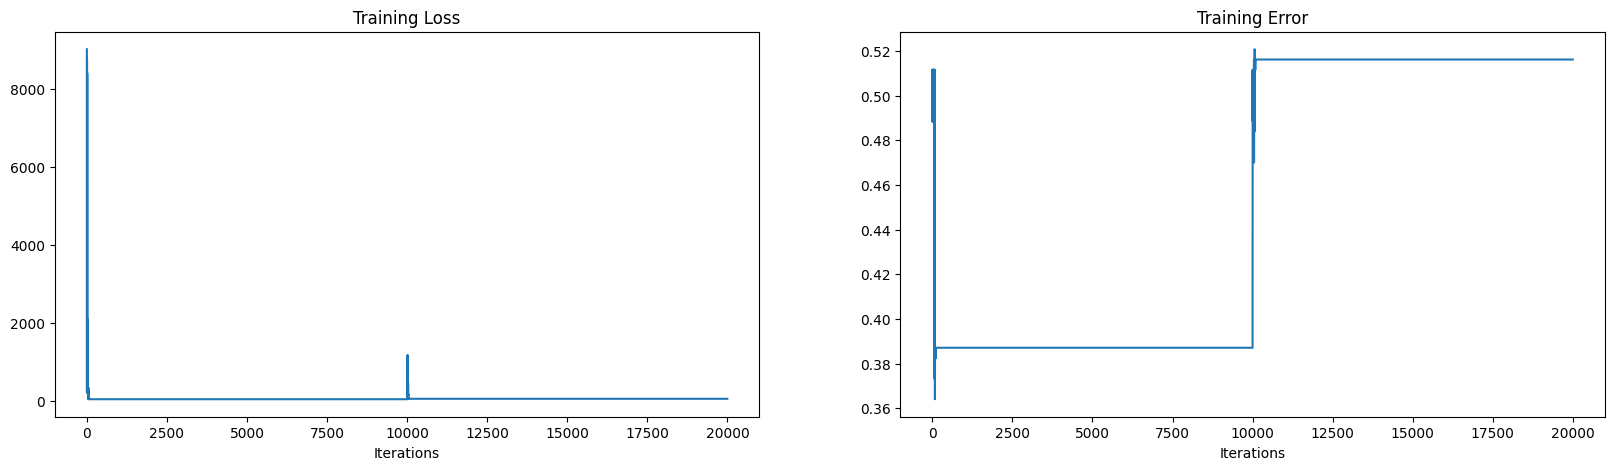

In [81]:
# Visualize in a diagram how the Loss and the training error change in the course of iteration.
# svm is called twice so this call needs to move or a blip is created in training loss because it continues to append
iterations = range(len(training_errors))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss")
axes[0].plot(iterations, losses)

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error")
axes[1].plot(iterations, training_errors)
plt.show()